# Diabetes Risk Models
This notebook trains and evaluates Logistic Regression and XGBoost models for diabetes prediction using `diabetes_012_health_indicators_BRFSS2015.csv`.
Excluded features: `AnyHealthcare`, `NoDocbcCost`, `Income`.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/diabetes_012_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
# Inspect target distribution
print('Shape:', df.shape)
print(df['Diabetes_012'].value_counts(dropna=False))
print(df['Diabetes_012'].value_counts(normalize=True) * 100)

Shape: (253680, 22)
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64
Diabetes_012
0.0    84.241170
2.0    13.933302
1.0     1.825528
Name: proportion, dtype: float64


In [4]:
# Select features, excluding AnyHealthcare, NoDocbcCost, Income
features = [
    'HighBP','HighChol','CholCheck','BMI','Smoker','Stroke','HeartDiseaseorAttack',
    'PhysActivity','Fruits','Veggies','HvyAlcoholConsump',
    'GenHlth','MentHlth','PhysHlth','DiffWalk','Sex','Age','Education'
]
df = df[features + ['Diabetes_012']].copy()
# Convert target to binary: 0 = no diabetes, 1 = prediabetes or diabetes
# The original dataset uses 0, 1, 2 labels for diabetes status.
df['Diabetes_012'] = (df['Diabetes_012'] > 0).astype(int)
# Drop rows with missing numeric values
df.dropna(subset=['BMI'], inplace=True)
print(df['Diabetes_012'].value_counts())
df.shape

Diabetes_012
0    213703
1     39977
Name: count, dtype: int64


(253680, 19)

In [5]:
# Define column groups
numeric_cols = ['BMI','MentHlth','PhysHlth','Age','Education']
nominal_cols = [c for c in features if c not in numeric_cols]
nominal_cols

['HighBP',
 'HighChol',
 'CholCheck',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'GenHlth',
 'DiffWalk',
 'Sex']

In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split

In [7]:
numeric_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
numeric_pipeline_no_scale = make_pipeline(SimpleImputer(strategy='median'))

tree_preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    (numeric_pipeline_no_scale, numeric_cols)
)

lr_preprocessor = make_column_transformer(
    (OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols),
    (numeric_pipeline, numeric_cols)
)

X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

In [8]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_lr_train = lr_preprocessor.fit_transform(X_train_raw)
X_lr_test = lr_preprocessor.transform(X_test_raw)

X_tree_train = tree_preprocessor.fit_transform(X_train_raw)
X_tree_test = tree_preprocessor.transform(X_test_raw)

In [9]:
# SMOTE and tuning for LogisticRegression and XGBoost
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV

sm = SMOTE(random_state=42)
X_lr_train_smote, y_train_smote = sm.fit_resample(X_lr_train, y_train)
X_tree_train_smote, y_train_smote = sm.fit_resample(X_tree_train, y_train)

# Logistic Regression tuning
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='liblinear')
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
lr_search = RandomizedSearchCV(lr, param_grid_lr, scoring='roc_auc', cv=3, n_iter=5, random_state=42)
lr_search.fit(X_lr_train_smote, y_train_smote)
lr = lr_search.best_estimator_
print('Best LR params:', lr_search.best_params_)

# XGBoost tuning
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.2f}')
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, use_label_encoder=False, eval_metric='logloss')
param_dist_xgb = {
    'n_estimators': [100, 200, 400],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(xgb, param_dist_xgb, scoring='roc_auc', cv=3, n_iter=8, random_state=42, n_jobs=-1)
xgb_search.fit(X_tree_train_smote, y_train_smote)
xboost = xgb_search.best_estimator_
print('Best XGBoost params:', xgb_search.best_params_)

print('Trained/optimized models: LogisticRegression, XGBoost')

Best LR params: {'C': 0.1}
scale_pos_weight = 5.35


c:\Users\SAYAN GHOSH\Health_AI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:16:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost params: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1}
Trained/optimized models: LogisticRegression, XGBoost


In [10]:
# Evaluation helpers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = {}
    metrics['model'] = name
    metrics['accuracy'] = accuracy_score(y_test, y_pred)
    metrics['precision'] = precision_score(y_test, y_pred, zero_division=0)
    metrics['recall'] = recall_score(y_test, y_pred, zero_division=0)
    metrics['f1'] = f1_score(y_test, y_pred, zero_division=0)
    try:
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_test)[:, 1]
            metrics['roc_auc'] = roc_auc_score(y_test, probs)
        else:
            metrics['roc_auc'] = np.nan
    except Exception:
        metrics['roc_auc'] = np.nan
    metrics['confusion_matrix'] = confusion_matrix(y_test, y_pred).tolist()
    return metrics

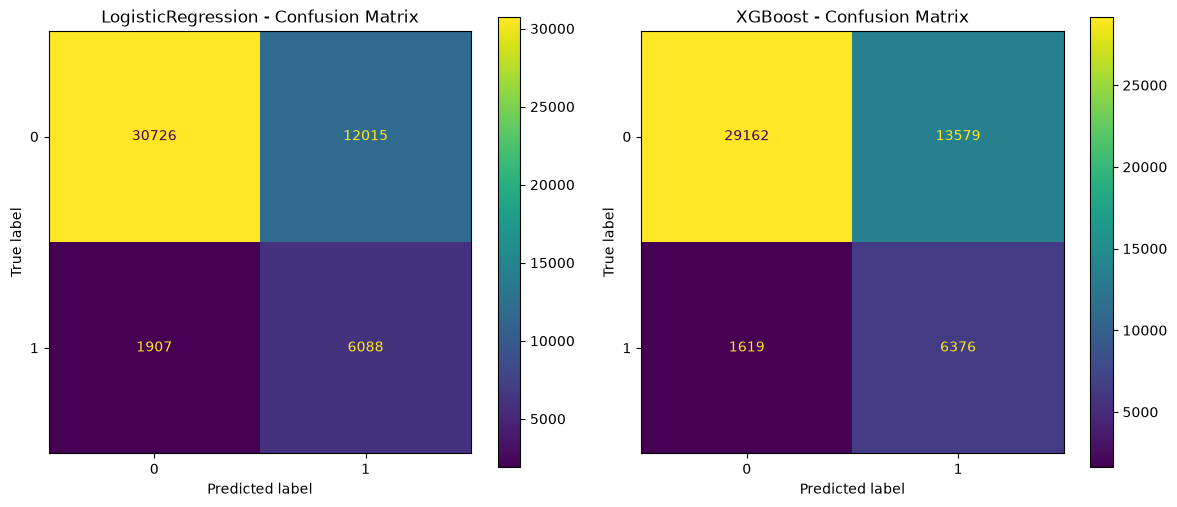

In [11]:
# Confusion matrices for LR and XGBoost
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.ravel()
models = [('LogisticRegression', lr, X_lr_test), ('XGBoost', xboost, X_tree_test)]
for idx, (name, model, X_test) in enumerate(models):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[idx])
    axes[idx].set_title(f'{name} - Confusion Matrix')
plt.tight_layout()
plt.show()

In [12]:
# Summary table
import pandas as pd
results = []
results.append(evaluate_model('LogisticRegression', lr, X_lr_test, y_test))
results.append(evaluate_model('XGBoost', xboost, X_tree_test, y_test))
rows = []
for r in results:
    rows.append({'model': r['model'], 'accuracy': r['accuracy'], 'precision': r['precision'], 'recall': r['recall'], 'f1': r['f1'], 'roc_auc': r.get('roc_auc', np.nan)})
summary_df = pd.DataFrame(rows).set_index('model')
display(summary_df)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.725599,0.336298,0.761476,0.466549,0.814721
XGBoost,0.700449,0.319519,0.797498,0.456243,0.817162


In [13]:
# Threshold tuning for Logistic Regression
y_prob = lr.predict_proba(X_lr_test)[:, 1]
thresholds = [0.05, 0.1, 0.2, 0.3, 0.5]
from sklearn.metrics import precision_score, recall_score, f1_score
rows = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    rows.append({'threshold': t, 'precision': prec, 'recall': rec, 'f1': f1})
thr_df = pd.DataFrame(rows).set_index('threshold')
display(thr_df)

,precision,recall,f1
threshold,,,
0.05,0.171045,0.997624,0.292022
0.10,0.191073,0.990494,0.320348
0.20,0.227896,0.956848,0.368116
0.30,0.263044,0.909944,0.408112
0.50,0.336298,0.761476,0.466549


In [14]:
# Final selection and metrics for LR with chosen threshold
final_threshold = 0.1
y_pred_final = (y_prob >= final_threshold).astype(int)
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score
roc_auc = roc_auc_score(y_test, y_prob)
recall = recall_score(y_test, y_pred_final, zero_division=0)
precision = precision_score(y_test, y_pred_final, zero_division=0)
f1 = f1_score(y_test, y_pred_final, zero_division=0)
final_summary = pd.DataFrame({'metric': ['roc_auc', 'precision', 'recall', 'f1', 'threshold'], 'value': [roc_auc, precision, recall, f1, final_threshold]}).set_index('metric')
display(final_summary)
print('Final Diabetes Model: Logistic Regression (balanced, tuned)')
print(f'ROC-AUC = {roc_auc:.2f}')
print(f'Recall (threshold={final_threshold}) = {recall:.2f}')

,value
metric,
roc_auc,0.814721
precision,0.191073
recall,0.990494
f1,0.320348
threshold,0.100000


Final Diabetes Model: Logistic Regression (balanced, tuned)
ROC-AUC = 0.81
Recall (threshold=0.1) = 0.99


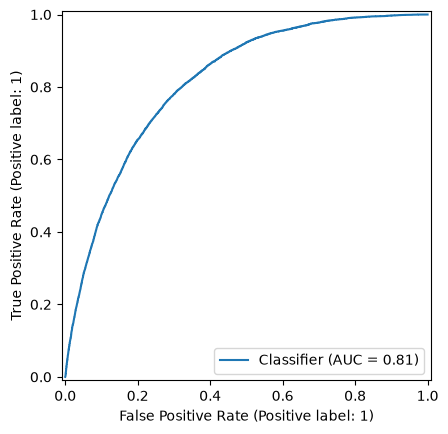

In [15]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

In [16]:

import os
import joblib

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(
    lr,
    os.path.join(MODELS_DIR, "diabetes_model.pkl")
)

joblib.dump(
    lr_preprocessor,
    os.path.join(MODELS_DIR, "diabetes_preprocessor.pkl")
)

joblib.dump(
    final_threshold,
    os.path.join(MODELS_DIR, "diabetes_threshold.pkl")
)

joblib.dump(
    X_train_raw.sample(1000, random_state=42),
    os.path.join(MODELS_DIR, "diabetes_background.pkl")
)

print("Diabetes model saved successfully!")

Diabetes model saved successfully!
